## Mini Project: COVID-19 Detection from Chest X-rays using CNN

### Objective

A healthcare startup aims to accelerate and improve COVID-19 diagnosis using deep learning technologies. The current testing procedures are time-consuming and rely heavily on manual radiological examination, which limits scalability in pandemic situations.

As a data scientist, your task is to build a Convolutional Neural Network (CNN) model that can automatically detect COVID-19 from chest X-ray images. This solution can help hospitals:

•	Reduce diagnosis time.

•	Minimize burden on radiologists.

•	Scale testing across regions with limited radiological expertise.

This project allows you to apply deep learning concepts, understand how CNNs process image data, and build real-world applications that can assist the medical community.


#### Dataset
### You will use the dataset provided in the following Kaggle project:

https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset

### The dataset contains:

•	COVID-19 chest X-ray images

•	Normal (no disease) chest X-ray images

•	Viral Pneumonia chest X-ray images


#### Data Dictionary

Each image is labelled into one of the following classes:

•	COVID-19 – Confirmed COVID infection.

•	Viral Pneumonia – Non-COVID lung infection.

•	Normal – No visible lung abnormality.


#### Tasks

1. Data Loading and Exploration

•	Import necessary libraries (os, cv2, matplotlib, tensorflow, keras etc.)

•	Import Covid19 dataset from Kaggle into colab using Kaggle API.

•	Load images from different folders and label them

•	Resize images to a fixed shape (e.g 128x128 or 224x224)

•	Display a few sample images from each class

•	Print dataset size per class


In [ ]:
# import necessary libraries

# Importing the libraries

import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras import layers
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image

In [ ]:
# Import Covid19 dataset from Kaggle into colab using Kaggle API.

!kaggle datasets download -d pranavraikokte/covid19-image-dataset

Dataset URL: https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset
License(s): CC-BY-SA-4.0
covid19-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Verify downloads
import os
print(os.listdir())

['.ipynb_checkpoints', 'Cancer_detection_CNN.py', 'CNN_model - Copy.ipynb', 'CNN_model.ipynb', 'CNN_model_updated.ipynb', 'CNN_model_v2.ipynb', 'Covid19-dataset', 'covid19-image-dataset.zip', 'Covid19_Chest_Xrays.docx', 'data', 'models', 'myenv', 'requirements.txt', 'runtime.txt']


In [ ]:
# Extracting the Zip  # unzip the downloaded file

import zipfile

zip_path = "covid19-image-dataset.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done!")


Extraction Done!


In [ ]:
# Check folder structure
# 
print(os.listdir("data"))
print(os.listdir("data/Covid19-dataset"))
print(os.listdir("data/Covid19-dataset/train"))
print(os.listdir("data/Covid19-dataset/test"))

['Covid19-dataset', 'Covid19-dataset-resized']
['test', 'train']
['Covid', 'Normal', 'Viral Pneumonia']
['Covid', 'Normal', 'Viral Pneumonia']


In [ ]:
# Define paths for training and testing data
train_dir = "data/Covid19-dataset/train"
test_dir = "data/Covid19-dataset/test"

In [ ]:
# Checking folder structure and number of images in each class
import os

train_dir = "data/Covid19-dataset/train"

for cls in os.listdir(train_dir):
    print(cls, ":", len(os.listdir(os.path.join(train_dir, cls))))

Covid : 111
Normal : 70
Viral Pneumonia : 70


#### •	Load images from different folders and label them

In [ ]:
import os
import numpy as np
from PIL import Image

IMG_SIZE = 128
train_dir = "data/Covid19-dataset/train"

images = []
labels = []

class_names = os.listdir(train_dir)

for label, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    
    for img_name in os.listdir(class_path)[:5]:  # only 5 images per class
        img_path = os.path.join(class_path, img_name)
        
        img = Image.open(img_path).convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE))
        
        images.append(np.array(img))
        labels.append(label)

print("Images shape:", np.array(images).shape)
print("Labels:", labels)
print("Class mapping:", dict(enumerate(class_names)))

Images shape: (15, 128, 128, 3)
Labels: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2]
Class mapping: {0: 'Covid', 1: 'Normal', 2: 'Viral Pneumonia'}


In [ ]:
# to check the image path
import os

img_path = "data/Covid19-dataset/train/Covid/0.png"

print(os.path.exists(img_path))  # Should be True

False


In [ ]:
# to check the image path
import os

folder = "data/Covid19-dataset/train/Covid"
print(os.listdir(folder))

['01.jpeg', '010.png', '012.jpeg', '015.jpg', '019.png', '02.jpeg', '020.jpg', '021.jpeg', '022.jpeg', '024.jpeg', '025.jpeg', '026.jpeg', '027.jpeg', '03.jpeg', '031.jpeg', '032.jpeg', '033.png', '039.jpeg', '04.png', '040.jpeg', '041.jpeg', '042.jpeg', '043.jpeg', '044.jpeg', '045.jpeg', '046.jpeg', '047.jpeg', '048.jpeg', '049.jpeg', '050.jpeg', '051.jpeg', '052.jpeg', '053.jpeg', '054.jpeg', '055.jpeg', '056.jpg', '057.jpeg', '058.jpeg', '059.jpeg', '06.jpeg', '060.jpeg', '061.jpg', '062.jpeg', '064.jpg', '065.jpeg', '067.jpg', '068.jpg', '069.jpg', '07.jpg', '071.jpg', '072.jpeg', '073.jpg', '074.jpg', '076.jpg', '078.jpeg', '079.jpeg', '08.jpeg', '080.jpg', '081.jpeg', '082.jpg', '083.jpeg', '084.jpeg', '085.jpeg', '086.jpg', '088.jpeg', '089.jpg', '09.png', '090.jpeg', '091.jpg', '092.png', 'COVID-00001.jpg', 'COVID-00002.jpg', 'COVID-00003a.jpg', 'COVID-00003b.jpg', 'COVID-00004.jpg', 'COVID-00005.jpg', 'COVID-00006.jpg', 'COVID-00007.jpg', 'COVID-00008.jpg', 'COVID-00009.jpg',

### •	Resize images to a fixed shape (e.g 128x128 or 224x224)

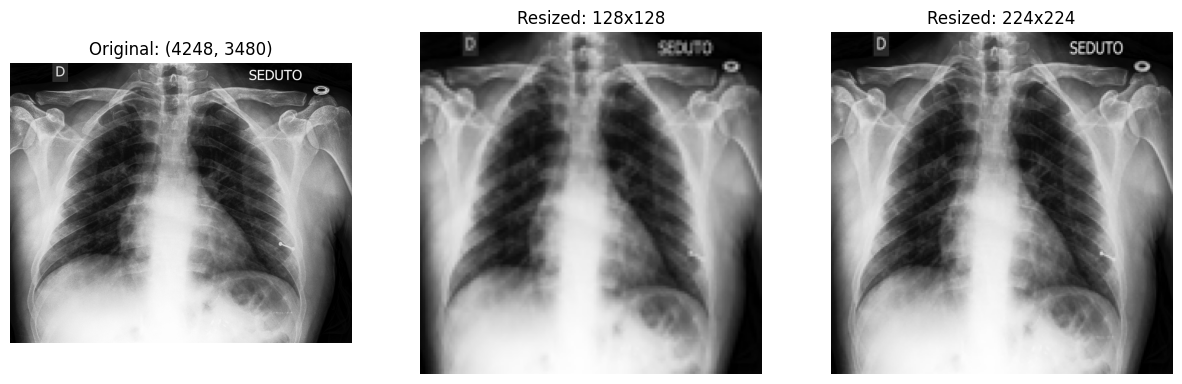

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

IMG_SIZE_1 = 128
IMG_SIZE_2 = 224

img_path = "data/Covid19-dataset/train/Covid/01.jpeg"

# Load original image
original_img = Image.open(img_path).convert('RGB')

# Resize images
img_128 = original_img.resize((IMG_SIZE_1, IMG_SIZE_1))
img_224 = original_img.resize((IMG_SIZE_2, IMG_SIZE_2))

# Display all
plt.figure(figsize=(15,5))

# Original
plt.subplot(1,3,1)
plt.imshow(original_img)
plt.title(f"Original: {original_img.size}")
plt.axis('off')

# 128x128
plt.subplot(1,3,2)
plt.imshow(img_128)
plt.title("Resized: 128x128")
plt.axis('off')

# 224x224
plt.subplot(1,3,3)
plt.imshow(img_224)
plt.title("Resized: 224x224")
plt.axis('off')

plt.show()

In [ ]:
import os
from PIL import Image

# Input and output directories
input_dir = "data/Covid19-dataset/train"
output_dir = "data/Covid19-dataset-resized/train"

IMG_SIZE = 224  # change to 128 if needed

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Loop through each class (Covid, Normal, etc.)
for class_name in os.listdir(input_dir):
    class_path = os.path.join(input_dir, class_name)
    
    # Skip if not a folder
    if not os.path.isdir(class_path):
        continue
    
    # Create corresponding output class folder
    output_class_path = os.path.join(output_dir, class_name)
    os.makedirs(output_class_path, exist_ok=True)
    
    # Loop through images in the class folder
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        
        try:
            # Open and resize image
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            
            # Save resized image
            save_path = os.path.join(output_class_path, img_name)
            img.save(save_path)
            
        except Exception as e:
            print(f"Skipping {img_name}: {e}")

print("✅ All images resized and saved!")

✅ All images resized and saved!


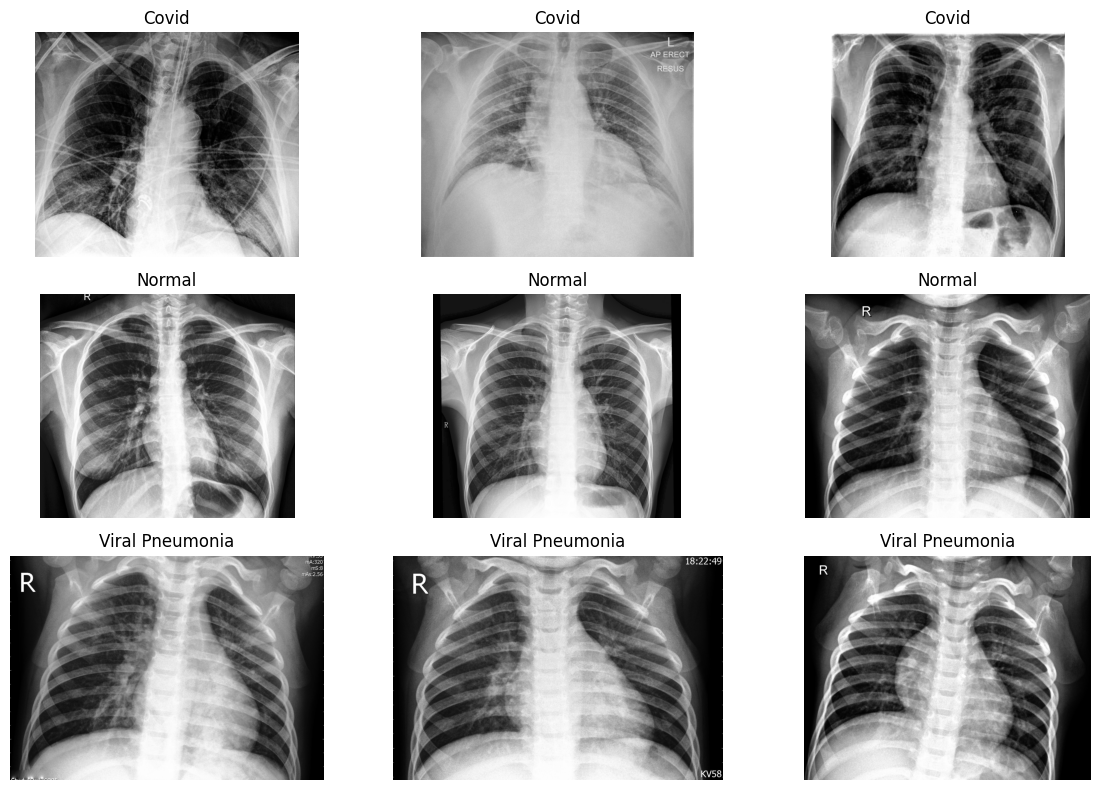

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Dataset path
train_dir = "data/Covid19-dataset/train"

# Number of images to show per class
num_samples = 3

# Get class names
class_names = os.listdir(train_dir)

plt.figure(figsize=(12, 8))

plot_index = 1

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    
    if not os.path.isdir(class_path):
        continue
    
    # Get all images in this class
    images = os.listdir(class_path)
    
    # Randomly pick samples
    sample_images = random.sample(images, min(num_samples, len(images)))
    
    for img_name in sample_images:
        img_path = os.path.join(class_path, img_name)
        
        try:
            img = Image.open(img_path).convert('RGB')
            
            plt.subplot(len(class_names), num_samples, plot_index)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')
            
            plot_index += 1
            
        except Exception as e:
            print(f"Skipping {img_name}: {e}")

plt.tight_layout()
plt.show()

In [ ]:
import os

train_dir = "data/Covid19-dataset/train"

class_names = os.listdir(train_dir)

print("📊 Dataset Size Per Class:\n")

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    
    if not os.path.isdir(class_path):
        continue
    
    num_images = len(os.listdir(class_path))
    
    print(f"{class_name}: {num_images} images")

📊 Dataset Size Per Class:

Covid: 111 images
Normal: 70 images
Viral Pneumonia: 70 images


#### Data Preprocessing

•	Normalize pixel values (scale from 0–255 to 0–1)
                          
•	Encode class labels using one-hot encoding or LabelEncoder

•	Split the data into training, validation and test sets (e.g 80-20%)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 1: Create generator
datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values
    validation_split=0.2        # Use 20% of training data for validation
)

# Step 2: Training data
train_data = datagen.flow_from_directory(
    "data/Covid19-dataset/train",
    target_size=(224, 224),         # Resize images to 224x224
    batch_size=32,                  # Number of images per batch
    class_mode='categorical',       # Use categorical labels for multi-class classification
    subset='training'               # Use the training subset
)

# Step 3: Validation data
val_data = datagen.flow_from_directory(
    "data/Covid19-dataset/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # Don't shuffle validation data to maintain order for evaluation
)

# Step 4: Test data (separate folder required)
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "data/Covid19-dataset/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Step 5: Check
print(train_data.class_indices)

images, labels = next(train_data)
print(images.shape, labels.shape)

Found 201 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Found 66 images belonging to 3 classes.
{'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}
(32, 224, 224, 3) (32, 3)


#### Exploratory Data Analysis (EDA)

•	Visualize class distribution using bar plots

•	Plot sample images with their class names

•	Observe patterns in data


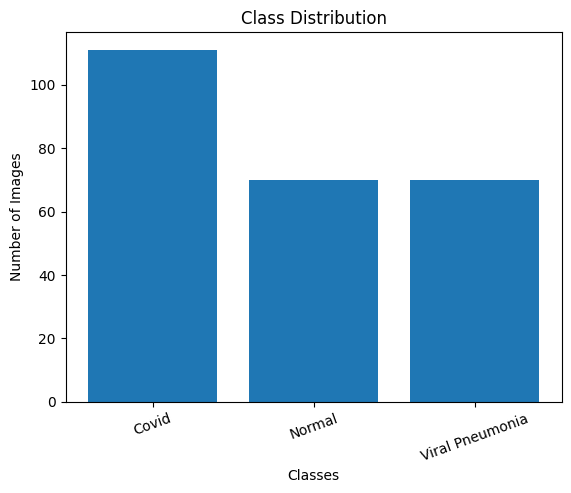

In [ ]:
import os
import matplotlib.pyplot as plt

train_dir = "data/Covid19-dataset/train"

class_names = sorted(os.listdir(train_dir))
counts = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    counts.append(len(os.listdir(class_path)))

# Plot
plt.figure()
plt.bar(class_names, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.show()

#### •	Plot sample images with their class names

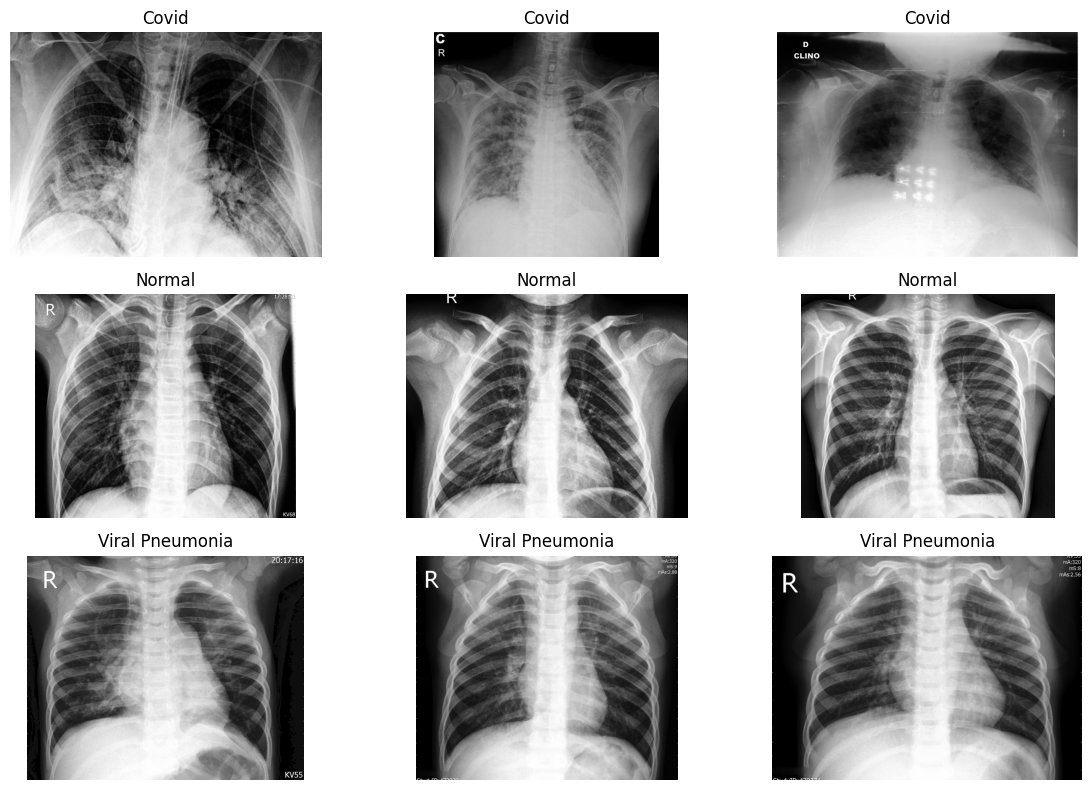

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

num_samples = 3
plt.figure(figsize=(12, 8))

plot_index = 1

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    
    sample_images = random.sample(images, min(num_samples, len(images)))
    
    for img_name in sample_images:
        img_path = os.path.join(class_path, img_name)
        
        img = Image.open(img_path).convert('RGB')
        
        plt.subplot(len(class_names), num_samples, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
        
        plot_index += 1

plt.tight_layout()
plt.show()

#### Observe Patterns in Data

#### Medical Image Patterns

 Medical Image Patterns

Covid images → more white patches (opacity)

Normal → clearer lung regions

Pneumonia → cloudy / diffused regions

#### Image Properties

In [ ]:
from PIL import Image
import numpy as np

img_path = os.path.join(train_dir, class_names[0], os.listdir(os.path.join(train_dir, class_names[0]))[0])

img = Image.open(img_path)
img_array = np.array(img)

print("Shape:", img_array.shape)
print("Min pixel:", img_array.min())
print("Max pixel:", img_array.max())

Shape: (3480, 4248, 3)
Min pixel: 0
Max pixel: 255


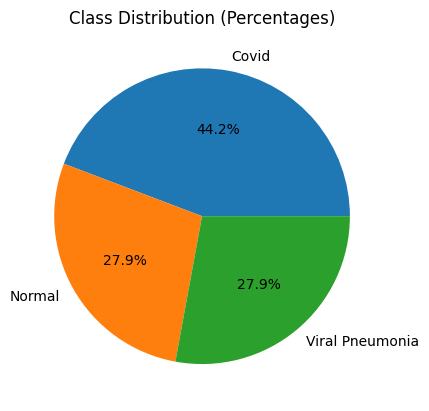

In [ ]:
# Distribution as Percentages
percentages = [count / sum(counts) * 100 for count in counts]

plt.figure()
plt.pie(percentages, labels=class_names, autopct='%1.1f%%')
plt.title("Class Distribution (Percentages)")
plt.show()

Insights:

- Dataset contains 3 classes: Covid, Normal, Viral Pneumonia
- Class distribution is (balanced / slightly imbalanced)
- Images vary in texture and intensity
- Covid images show opacity patterns
- Data is suitable for CNN-based classification

#### 4. CNN Model Building

Create and train multiple CNN architectures:

•	Model 1: Basic CNN

o	Conv2D -> MaxPooling -> Flatten -> Dense


In [ ]:
# step -1: Import Required Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


#### Model-1 a (Basic CNN)

In [ ]:
# Step 2: Build the Model
model_1a = Sequential([
    
    # Convolution layer
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    # Pooling layer
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flatten
    Flatten(),
    
    # Fully connected layer
    Dense(128, activation='relu'),
    
    # Output layer (3 classes)
    Dense(3, activation='softmax')
])


c:\Anitha_official\DataScience_IITG\0_Assignments_and_Projects\Projects\CNN\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Step 3: Compile the Model
model_1a.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
#step 4 - model summary
model_1a.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 5: Train the Model
history_model_1a = model_1a.fit(train_data, validation_data=val_data, epochs=10)    

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 894ms/step - accuracy: 0.4826 - loss: 2.3239 - val_accuracy: 0.4400 - val_loss: 1.0408
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 758ms/step - accuracy: 0.7811 - loss: 0.7088 - val_accuracy: 0.4400 - val_loss: 1.1072
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 870ms/step - accuracy: 0.7811 - loss: 0.4270 - val_accuracy: 0.8400 - val_loss: 0.3916
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 915ms/step - accuracy: 0.8905 - loss: 0.2659 - val_accuracy: 0.9000 - val_loss: 0.3803
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9154 - loss: 0.1856 - val_accuracy: 0.9000 - val_loss: 0.2547
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 901ms/step - accuracy: 0.9453 - loss: 0.0936 - val_accuracy: 0.9400 - val_loss: 0.2001
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 922ms/step - accuracy: 0.9950 - loss: 0.0318 - val_accuracy: 0.9400 - val_loss: 0.2106
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 918ms/step - accuracy: 0.9801 - loss: 0.0419 - val_accuracy: 0.9200 - val_loss: 0.

#### Model 1a — Evaluate on Test Set

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.9091 - loss: 0.2781
Model 1a Test Loss: 0.2781  |  Test Accuracy: 0.9091
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step

Classification Report:
                 precision    recall  f1-score   support

          Covid       0.96      1.00      0.98        26
         Normal       0.89      0.85      0.87        20
Viral Pneumonia       0.85      0.85      0.85        20

       accuracy                           0.91        66
      macro avg       0.90      0.90      0.90        66
   weighted avg       0.91      0.91      0.91        66



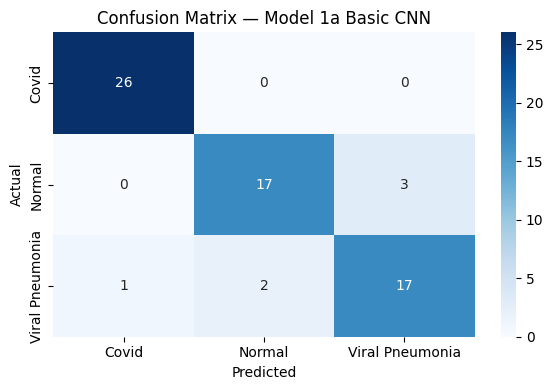

ROC-AUC Score: 0.9761
Accuracy: 0.9091  |  F1 Score: 0.9083
model_1a saved.


In [ ]:
import os
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("models", exist_ok=True)

# Evaluate on test set
test_loss_1a, test_acc_1a = model_1a.evaluate(test_data)
print(f"Model 1a Test Loss: {test_loss_1a:.4f}  |  Test Accuracy: {test_acc_1a:.4f}")

# Predict on test set (consistent with evaluate)
test_data.reset()
y_true_1a   = test_data.classes
y_probs_1a  = model_1a.predict(test_data)
y_pred_1a   = np.argmax(y_probs_1a, axis=1)

class_labels = list(test_data.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true_1a, y_pred_1a, target_names=class_labels))

# Confusion matrix
cm_1a = confusion_matrix(y_true_1a, y_pred_1a)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_1a, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title("Confusion Matrix — Model 1a Basic CNN")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

# ROC-AUC
y_bin_1a  = label_binarize(y_true_1a, classes=[0, 1, 2])
roc_1a    = roc_auc_score(y_bin_1a, y_probs_1a, multi_class='ovr')
print(f"ROC-AUC Score: {roc_1a:.4f}")

# Scalar metrics
acc_1a = accuracy_score(y_true_1a, y_pred_1a)
f1_1a  = f1_score(y_true_1a, y_pred_1a, average='weighted')
print(f"Accuracy: {acc_1a:.4f}  |  F1 Score: {f1_1a:.4f}")
train_acc_1a = history_model_1a.history['accuracy'][-1]
val_acc_1a   = history_model_1a.history['val_accuracy'][-1]

# Save
model_1a.save("models/model_1a.keras", include_optimizer=False)
print("model_1a saved.")


#### Model 1a — Training vs Validation (Overfitting Check)

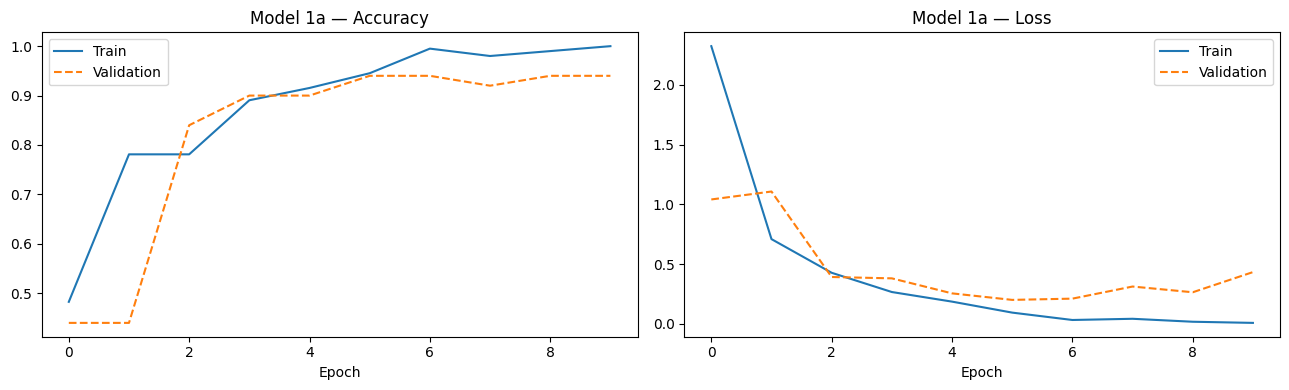

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_model_1a.history['accuracy'],     label='Train')
axes[0].plot(history_model_1a.history['val_accuracy'], label='Validation', linestyle='--')
axes[0].set_title("Model 1a — Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history_model_1a.history['loss'],     label='Train')
axes[1].plot(history_model_1a.history['val_loss'], label='Validation', linestyle='--')
axes[1].set_title("Model 1a — Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


#### Model 1b — Deep CNN (BatchNorm + Dropout)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model_1b = Sequential([
    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model_1b.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_1b.summary()


c:\Anitha_official\DataScience_IITG\0_Assignments_and_Projects\Projects\CNN\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,715 (49.36 MB)

 Trainable params: 12,939,267 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

history_model_1b = model_1b.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6816 - loss: 9.7673 - val_accuracy: 0.2800 - val_loss: 14.0632
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9403 - loss: 4.2446 - val_accuracy: 0.3000 - val_loss: 6.6826
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9453 - loss: 0.5723 - val_accuracy: 0.3000 - val_loss: 9.1757
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9502 - loss: 1.0146 - val_accuracy: 0.4600 - val_loss: 4.2076
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9453 - loss: 0.7007 - val_accuracy: 0.5800 - val_loss: 6.3247
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9701 - loss: 0.5477 - val_accuracy: 0.4400 - val_loss: 25.6087
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9851 - loss: 0.3113 - val_accuracy: 0.4400 - val_loss: 38.4345


#### Model 1b — Evaluate on Test Set

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.4545 - loss: 4.6718
Model 1b Test Loss: 4.6718  |  Test Accuracy: 0.4545
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step

Classification Report:
                 precision    recall  f1-score   support

          Covid       0.61      0.42      0.50        26
         Normal       0.40      0.95      0.57        20
Viral Pneumonia       0.00      0.00      0.00        20

       accuracy                           0.45        66
      macro avg       0.34      0.46      0.36        66
   weighted avg       0.36      0.45      0.37        66



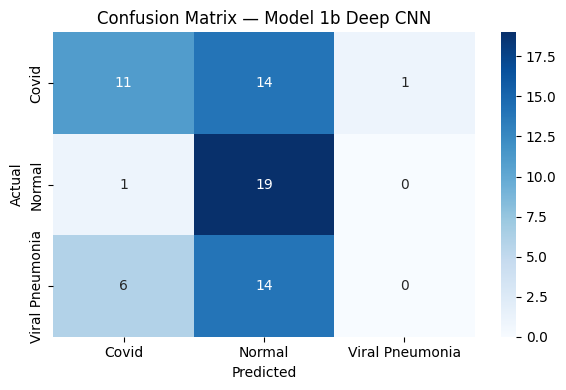

ROC-AUC Score: 0.6857
Accuracy: 0.4545  |  F1 Score: 0.3688
model_1b saved.


In [ ]:
# Evaluate on test set
test_loss_1b, test_acc_1b = model_1b.evaluate(test_data)
print(f"Model 1b Test Loss: {test_loss_1b:.4f}  |  Test Accuracy: {test_acc_1b:.4f}")

# Predict on test set
test_data.reset()
y_true_1b  = test_data.classes
y_probs_1b = model_1b.predict(test_data)
y_pred_1b  = np.argmax(y_probs_1b, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_1b, y_pred_1b, target_names=class_labels))

cm_1b = confusion_matrix(y_true_1b, y_pred_1b)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_1b, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title("Confusion Matrix — Model 1b Deep CNN")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

y_bin_1b = label_binarize(y_true_1b, classes=[0, 1, 2])
roc_1b   = roc_auc_score(y_bin_1b, y_probs_1b, multi_class='ovr')
print(f"ROC-AUC Score: {roc_1b:.4f}")

acc_1b = accuracy_score(y_true_1b, y_pred_1b)
f1_1b  = f1_score(y_true_1b, y_pred_1b, average='weighted')
print(f"Accuracy: {acc_1b:.4f}  |  F1 Score: {f1_1b:.4f}")
train_acc_1b = history_model_1b.history['accuracy'][-1]
val_acc_1b   = history_model_1b.history['val_accuracy'][-1]

model_1b.save("models/model_1b.keras", include_optimizer=False)
print("model_1b saved.")


#### Model 1b — Training vs Validation (Overfitting Check)

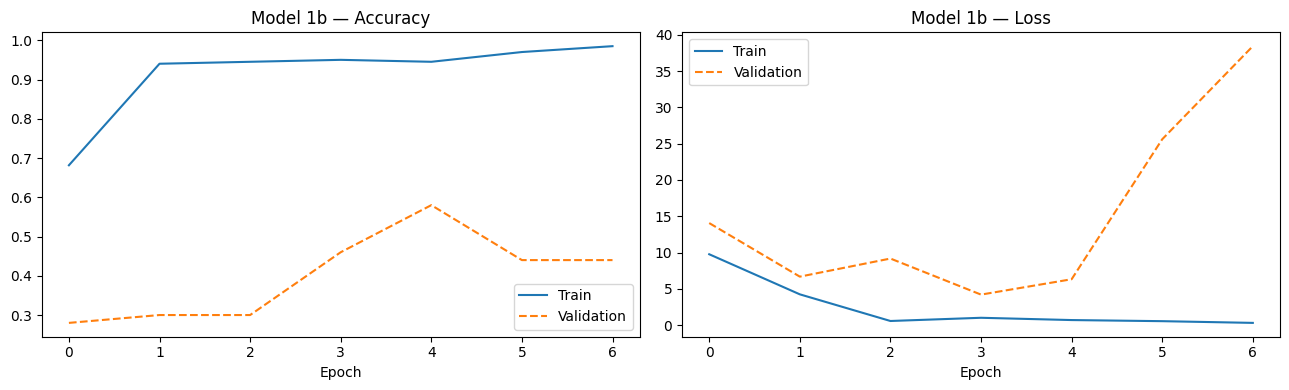

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_model_1b.history['accuracy'],     label='Train')
axes[0].plot(history_model_1b.history['val_accuracy'], label='Validation', linestyle='--')
axes[0].set_title("Model 1b — Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history_model_1b.history['loss'],     label='Train')
axes[1].plot(history_model_1b.history['val_loss'], label='Validation', linestyle='--')
axes[1].set_title("Model 1b — Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


#### Model 2 — Transfer Learning (VGG16)

Freeze base layers, add a custom classification head, then fine-tune the last 4 layers.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load VGG16 without top layers
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_vgg.layers:
    layer.trainable = False

# Custom head
x      = base_vgg.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.3)(x)
out_2  = Dense(3, activation='softmax')(x)

model_2 = Model(inputs=base_vgg.input, outputs=out_2)
model_2.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model_2.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Fine-tune last 4 VGG16 layers
for layer in base_vgg.layers[-4:]:
    layer.trainable = True

model_2.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_model_2 = model_2.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ]
)


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.3980 - loss: 1.1423 - val_accuracy: 0.4800 - val_loss: 1.0489 - learning_rate: 1.0000e-05
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.4080 - loss: 1.0799 - val_accuracy: 0.4800 - val_loss: 0.9912 - learning_rate: 1.0000e-05
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.5224 - loss: 0.9564 - val_accuracy: 0.5800 - val_loss: 0.9331 - learning_rate: 1.0000e-05
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - accuracy: 0.5572 - loss: 0.9258 - val_accuracy: 0.7000 - val_loss: 0.8767 - learning_rate: 1.0000e-05
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - accuracy: 0.6766 - loss: 0.8009 - val_accuracy: 0.7000 - val_loss: 0.8196 - learning_rate: 1.0000e-05
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 6s/step - accuracy: 0.7562 - loss: 0.7332 - val_accuracy: 0.7400 - val_loss: 0.7651 - learning_rate: 1.0000e-05
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 6s/step - accuracy: 0.7562 - loss: 0.6561 - val_

#### Model 2 — Evaluate on Test Set

3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.9242 - loss: 0.2988
VGG16 Test Loss: 0.2988  |  Test Accuracy: 0.9242
2/3 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step WARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000011C830AAC00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step

Classification Report:
                 precision    recall  f1-score   support

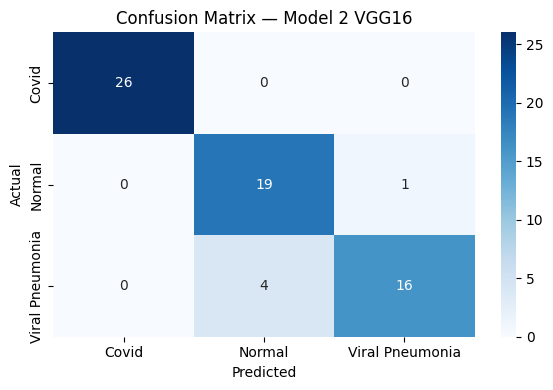

ROC-AUC Score: 0.9877
Accuracy: 0.9242  |  F1 Score: 0.9238
Model 2 saved.


In [ ]:
# Evaluate on test set
test_loss_2, test_acc_2 = model_2.evaluate(test_data)
print(f"VGG16 Test Loss: {test_loss_2:.4f}  |  Test Accuracy: {test_acc_2:.4f}")

# Predict on test set
test_data.reset()
y_true_2  = test_data.classes
y_probs_2 = model_2.predict(test_data)
y_pred_2  = np.argmax(y_probs_2, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_2, y_pred_2, target_names=class_labels))

cm_2 = confusion_matrix(y_true_2, y_pred_2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_2, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title("Confusion Matrix — Model 2 VGG16")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

y_bin_2 = label_binarize(y_true_2, classes=[0, 1, 2])
roc_2   = roc_auc_score(y_bin_2, y_probs_2, multi_class='ovr')
print(f"ROC-AUC Score: {roc_2:.4f}")

acc_2 = accuracy_score(y_true_2, y_pred_2)
f1_2  = f1_score(y_true_2, y_pred_2, average='weighted')
print(f"Accuracy: {acc_2:.4f}  |  F1 Score: {f1_2:.4f}")
train_acc_2 = history_model_2.history['accuracy'][-1]
val_acc_2   = history_model_2.history['val_accuracy'][-1]

model_2.save("models/model_2_vgg16.keras", include_optimizer=False)
print("Model 2 saved.")


#### Model 2 — Training vs Validation (Overfitting Check)

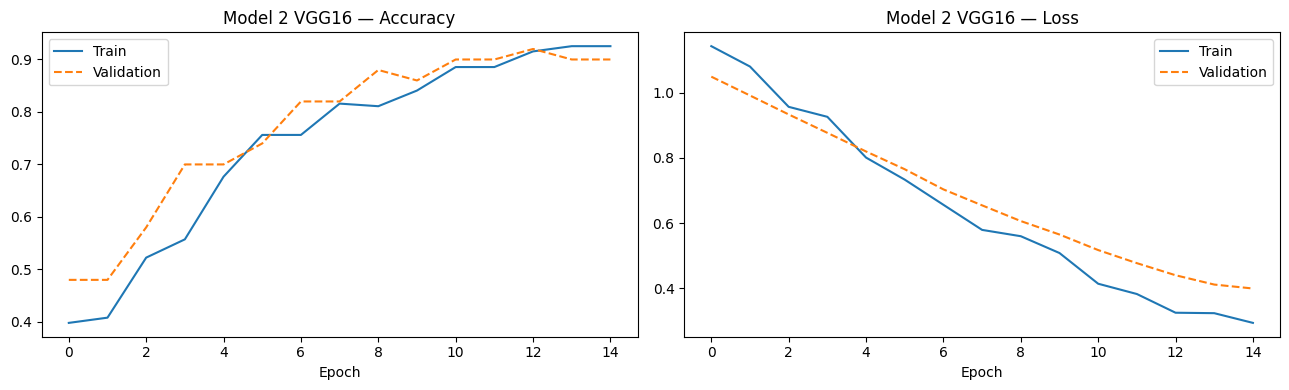

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_model_2.history['accuracy'],     label='Train')
axes[0].plot(history_model_2.history['val_accuracy'], label='Validation', linestyle='--')
axes[0].set_title("Model 2 VGG16 — Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history_model_2.history['loss'],     label='Train')
axes[1].plot(history_model_2.history['val_loss'], label='Validation', linestyle='--')
axes[1].set_title("Model 2 VGG16 — Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


#### Model 3 — Transfer Learning + Data Augmentation (ResNet50)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmented generators
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

aug_train_data = aug_datagen.flow_from_directory(
    "data/Covid19-dataset/train",
    target_size=(224, 224), batch_size=32,
    class_mode='categorical', subset='training'
)

aug_val_data = aug_datagen.flow_from_directory(
    "data/Covid19-dataset/train",
    target_size=(224, 224), batch_size=32,
    class_mode='categorical', subset='validation', shuffle=False
)

print("Augmented generators ready.")
print("Class indices:", aug_train_data.class_indices)


Found 201 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Augmented generators ready.
Class indices: {'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}


In [ ]:
# Build ResNet50 model
base_res = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_res.layers:
    layer.trainable = False

x      = base_res.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.3)(x)
out_3  = Dense(3, activation='softmax')(x)

model_3 = Model(inputs=base_res.input, outputs=out_3)
model_3.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model_3.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_model_3 = model_3.fit(
    aug_train_data,
    validation_data=aug_val_data,
    epochs=15,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]
)


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.4080 - loss: 1.2095 - val_accuracy: 0.4400 - val_loss: 1.0653 - learning_rate: 1.0000e-04
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.3582 - loss: 1.1129 - val_accuracy: 0.4600 - val_loss: 1.0686 - learning_rate: 1.0000e-04
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.3980 - loss: 1.1609 - val_accuracy: 0.4400 - val_loss: 1.0492 - learning_rate: 1.0000e-04
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.4328 - loss: 1.0909 - val_accuracy: 0.4400 - val_loss: 1.0382 - learning_rate: 1.0000e-04
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.4080 - loss: 1.0861 - val_accuracy: 0.4400 - val_loss: 1.0266 - learning_rate: 1.0000e-04
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step - accuracy: 0.4577 - loss: 1.0806 - val_accuracy: 0.4400 - val_loss: 1.0246 - learning_rate: 1.0000e-04
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.4677 - loss: 1.0377 - val_

#### Model 3 — Evaluate on Test Set

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 916ms/step - accuracy: 0.6667 - loss: 0.8773
ResNet50 Test Loss: 0.8773  |  Test Accuracy: 0.6667
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step

Classification Report:
                 precision    recall  f1-score   support

          Covid       0.70      1.00      0.83        26
         Normal       0.62      0.90      0.73        20
Viral Pneumonia       0.00      0.00      0.00        20

       accuracy                           0.67        66
      macro avg       0.44      0.63      0.52        66
   weighted avg       0.46      0.67      0.55        66



c:\Anitha_official\DataScience_IITG\0_Assignments_and_Projects\Projects\CNN\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Anitha_official\DataScience_IITG\0_Assignments_and_Projects\Projects\CNN\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Anitha_official\DataScience_IITG\0_Assignments_and_Projects\Projects\CNN\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted

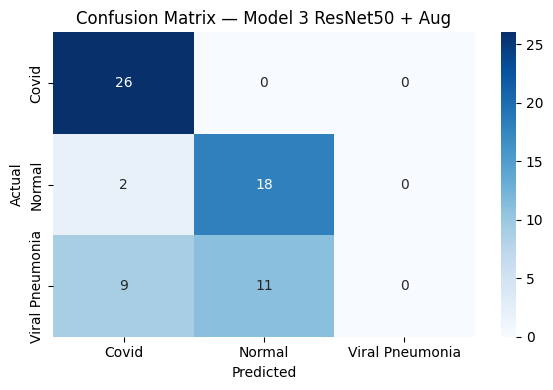

ROC-AUC Score: 0.8628
Accuracy: 0.6667  |  F1 Score: 0.5478
Model 3 saved.


In [ ]:
# Evaluate on test set
test_loss_3, test_acc_3 = model_3.evaluate(test_data)
print(f"ResNet50 Test Loss: {test_loss_3:.4f}  |  Test Accuracy: {test_acc_3:.4f}")

# Predict on test set
test_data.reset()
y_true_3  = test_data.classes
y_probs_3 = model_3.predict(test_data)
y_pred_3  = np.argmax(y_probs_3, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_3, y_pred_3, target_names=class_labels))

cm_3 = confusion_matrix(y_true_3, y_pred_3)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_3, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title("Confusion Matrix — Model 3 ResNet50 + Aug")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

y_bin_3 = label_binarize(y_true_3, classes=[0, 1, 2])
roc_3   = roc_auc_score(y_bin_3, y_probs_3, multi_class='ovr')
print(f"ROC-AUC Score: {roc_3:.4f}")

acc_3 = accuracy_score(y_true_3, y_pred_3)
f1_3  = f1_score(y_true_3, y_pred_3, average='weighted')
print(f"Accuracy: {acc_3:.4f}  |  F1 Score: {f1_3:.4f}")
train_acc_3 = history_model_3.history['accuracy'][-1]
val_acc_3   = history_model_3.history['val_accuracy'][-1]

model_3.save("models/model_3_resnet50_aug.keras", include_optimizer=False)
print("Model 3 saved.")


#### Model 3 — Training vs Validation (Overfitting Check)

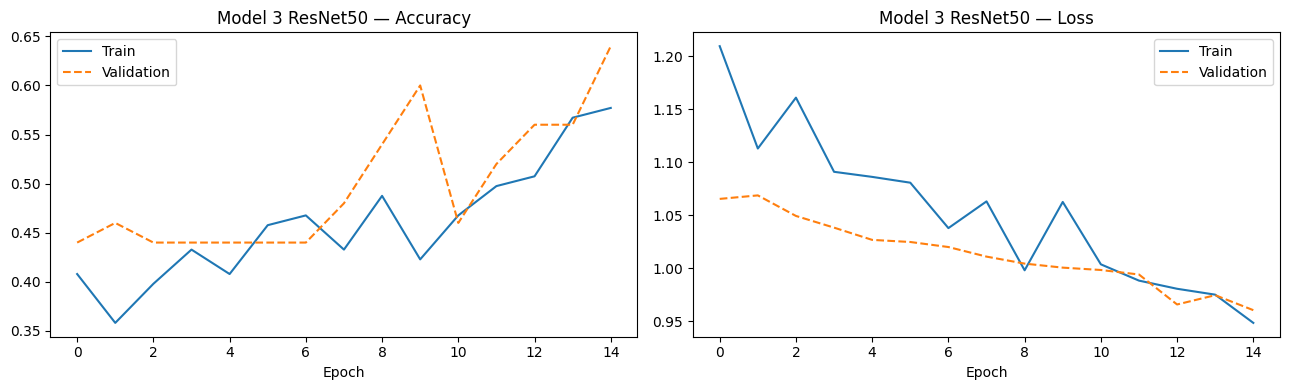

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_model_3.history['accuracy'],     label='Train')
axes[0].plot(history_model_3.history['val_accuracy'], label='Validation', linestyle='--')
axes[0].set_title("Model 3 ResNet50 — Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history_model_3.history['loss'],     label='Train')
axes[1].plot(history_model_3.history['val_loss'], label='Validation', linestyle='--')
axes[1].set_title("Model 3 ResNet50 — Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


#### 6. Handle Class Imbalance

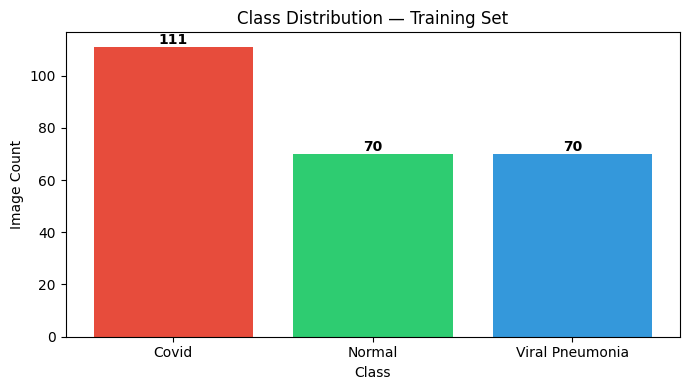

Class Weights: {0: np.float64(0.7537537537537538), 1: np.float64(1.1952380952380952), 2: np.float64(1.1952380952380952)}


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

train_dir_ci = "data/Covid19-dataset/train"
class_names_sorted = sorted(os.listdir(train_dir_ci))
counts_ci = [len(os.listdir(os.path.join(train_dir_ci, c))) for c in class_names_sorted]

# Visualize class distribution
plt.figure(figsize=(7, 4))
bars = plt.bar(class_names_sorted, counts_ci, color=['#e74c3c','#2ecc71','#3498db'])
plt.title("Class Distribution — Training Set")
plt.xlabel("Class"); plt.ylabel("Image Count")
for bar, v in zip(bars, counts_ci):
    plt.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

# Compute class weights
all_labels_ci = []
for idx, cls in enumerate(class_names_sorted):
    all_labels_ci.extend([idx] * len(os.listdir(os.path.join(train_dir_ci, cls))))

weights_ci    = compute_class_weight('balanced', classes=np.unique(all_labels_ci), y=all_labels_ci)
class_weights = dict(enumerate(weights_ci))
print("Class Weights:", class_weights)


In [ ]:
# Retrain model_1b with class weights to handle imbalance
history_balanced = model_1b.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)
print("Balanced training done.")


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9801 - loss: 0.1474 - val_accuracy: 0.4200 - val_loss: 7.8643
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9851 - loss: 0.1516 - val_accuracy: 0.4400 - val_loss: 27.2741
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9900 - loss: 0.2225 - val_accuracy: 0.4400 - val_loss: 44.4557
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9950 - loss: 0.0174 - val_accuracy: 0.4400 - val_loss: 57.6247
Balanced training done.


#### 7. Model Tuning with Keras Tuner

In [ ]:
# ── Model Tuning: Try different learning rates and pick the best ──────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

learning_rates = [1e-2, 1e-3, 1e-4]
results = {}

for lr in learning_rates:
    print(f"\nTraining with lr={lr}")
    m = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ])
    m.compile(optimizer=Adam(lr), loss='categorical_crossentropy', metrics=['accuracy'])
    hist = m.fit(
        train_data,
        validation_data=val_data,
        epochs=5,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
        verbose=0
    )
    val_acc = max(hist.history['val_accuracy'])
    results[lr] = (val_acc, m, hist)          # ← store hist too
    print(f"  Best val_accuracy: {val_acc:.4f}")

# Pick the best
best_lr          = max(results, key=lambda lr: results[lr][0])
best_model       = results[best_lr][1]
best_hist        = results[best_lr][2]
train_acc_best   = best_hist.history['accuracy'][-1]   # ← now defined
val_acc_best     = best_hist.history['val_accuracy'][-1] # ← now defined
print(f"\nBest lr={best_lr}  |  val_accuracy={val_acc_best:.4f}")



Training with lr=0.01


c:\Anitha_official\DataScience_IITG\0_Assignments_and_Projects\Projects\CNN\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Best val_accuracy: 0.7800

Training with lr=0.001
  Best val_accuracy: 0.9200

Training with lr=0.0001
  Best val_accuracy: 0.8800

Best lr=0.001  |  val_accuracy=0.9200


In [ ]:
# Evaluate best tuned model on test set
test_loss_best, test_acc_best = best_model.evaluate(test_data)
print(f"Best Tuned Model Test Accuracy: {test_acc_best:.4f}")                                                   

test_data.reset()
y_true_best  = test_data.classes
y_probs_best = best_model.predict(test_data)
y_pred_best  = np.argmax(y_probs_best, axis=1)

from sklearn.metrics import f1_score
f1_best = f1_score(y_true_best, y_pred_best, average='weighted')
print(f"F1 Score: {f1_best:.4f}")

best_model.save("models/best_tuned_model.keras", include_optimizer=False)
print("Best model saved.")


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.8333 - loss: 0.3056
Best Tuned Model Test Accuracy: 0.8333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step
F1 Score: 0.8329
Best model saved.


#### 8. Model Comparison Table

In [ ]:


# ── Model Comparison Table ────────────────────────────────────────────────────
import pandas as pd

comparison_data = [
    {"Model": "Basic CNN (1a)",      "Train Acc": round(train_acc_1a, 4), "Test Acc": round(test_acc_1a, 4),   "F1 Score": round(f1_1a, 4), "ROC-AUC": round(roc_1a, 4), "Overfitting": "Y" if (train_acc_1a - val_acc_1a) > 0.1 else "N"},
    {"Model": "Deep CNN (1b)",       "Train Acc": round(train_acc_1b, 4), "Test Acc": round(test_acc_1b, 4),   "F1 Score": round(f1_1b, 4), "ROC-AUC": round(roc_1b, 4), "Overfitting": "Y" if (train_acc_1b - val_acc_1b) > 0.1 else "N"},
    {"Model": "VGG16 Transfer (2)",  "Train Acc": round(train_acc_2,  4), "Test Acc": round(test_acc_2,  4),   "F1 Score": round(f1_2,  4), "ROC-AUC": round(roc_2,  4), "Overfitting": "Y" if (train_acc_2  - val_acc_2)  > 0.1 else "N"},
    {"Model": "ResNet50 + Aug (3)",  "Train Acc": round(train_acc_3,  4), "Test Acc": round(test_acc_3,  4),   "F1 Score": round(f1_3,  4), "ROC-AUC": round(roc_3,  4), "Overfitting": "Y" if (train_acc_3  - val_acc_3)  > 0.1 else "N"},
    {"Model": "Best Tuned Model",    "Train Acc": round(train_acc_best,4), "Test Acc": round(test_acc_best, 4), "F1 Score": round(f1_best,4), "ROC-AUC": "—",             "Overfitting": "Y" if (train_acc_best - val_acc_best) > 0.1 else "N"},
]

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


Training with lr=0.01


c:\Anitha_official\DataScience_IITG\0_Assignments_and_Projects\Projects\CNN\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Best val_accuracy: 0.8200

Training with lr=0.001
  Best val_accuracy: 0.9400

Training with lr=0.0001
  Best val_accuracy: 0.8800

Best lr=0.001  |  val_accuracy=0.9000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.8485 - loss: 0.3800
Best Tuned Model Test Accuracy: 0.8485
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step
F1 Score: 0.8437
Best model saved.
             Model  Train Acc  Test Acc  F1 Score ROC-AUC Overfitting
    Basic CNN (1a)     1.0000    0.9091    0.9083  0.9761           N
     Deep CNN (1b)     0.9851    0.4545    0.3688  0.6857           Y
VGG16 Transfer (2)     0.9254    0.9242    0.9238  0.9877           N
ResNet50 + Aug (3)     0.5771    0.6667    0.5478  0.8628           N
  Best Tuned Model     0.9652    0.8485    0.8437       —           N


#### 9. Streamlit Web App Link



import streamlit as st
import tensorflow as tf
import numpy as np
import os
from pathlib import Path
from PIL import Image
import io
import gdown
import zipfile
import matplotlib.pyplot as plt
import streamlit.components.v1 as components

# Set page configuration
st.set_page_config(
    page_title="COVID-19 X-Ray Detector",
    page_icon="🫁",
    layout="wide"
)

# Global styles for improved look-and-feel
st.markdown("""
<style>
:root{
    --bg-1: #071029; /* deep navy */
    --bg-2: #0b1220; /* very dark */
    --card: #081428;
    --text: #e6f6ff;
    --muted: #9fb7c8;
    --accent-start: #06b6d4; /* vivid cyan */
    --accent-end: #ff7a18;   /* warm orange */
    --uploader-bg: #9be7ff; /* light blue for uploader */
    --uploader-text: #000000;
    --sidebar-bg: rgba(200, 255, 220, 0.06); /* subtle light green */
    --sidebar-border: rgba(200, 255, 220, 0.12);
}
body, .stApp {
    background: linear-gradient(180deg,var(--bg-1),var(--bg-2));
    color: var(--text);
    font-family: Inter, system-ui, -apple-system, 'Segoe UI', Roboto, 'Helvetica Neue', Arial;
}
.block-container{padding:2rem 1.5rem; max-width:1100px; margin:0 auto}
.sidebar .sidebar-content{
    background: var(--sidebar-bg);
    padding:1rem;
    border-radius:10px;
    border:1px solid var(--sidebar-border);
}
.result-card{
    background:var(--card);
    padding:18px;
    border-radius:12px;
    box-shadow:0 12px 40px rgba(2,6,23,0.6);
    text-align:center;
}
.result-title{margin:0; color:var(--text); font-size:20px; font-weight:700}
.result-confidence{color:var(--muted); font-size:16px; margin-top:8px}
.stButton>button{
    background: linear-gradient(90deg,var(--accent-start),var(--accent-end));
    color:#031026;
    border-radius:10px;
    padding:10px 14px;
    font-weight:700;
    box-shadow:0 10px 30px rgba(6,182,212,0.12);
}
.stButton>button:hover{filter:brightness(1.06); transform:translateY(-1px)}
img{border-radius:8px; box-shadow:0 16px 48px rgba(2,6,23,0.6)}
.prediction-card{background:linear-gradient(180deg, rgba(255,255,255,0.02), rgba(255,255,255,0.01)); padding:14px; border-radius:12px; border:1px solid rgba(255,255,255,0.03)}

/* File uploader visibility on dark background (high-contrast) */
.stFileUploader, input[type="file"] {
    color: var(--text) !important;
    background: rgba(255,255,255,0.08) !important;
    border-radius: 10px;
    padding: 8px;
    border: 1px solid rgba(255,255,255,0.08) !important;
}
.stFileUploader .stButton>button{ color: #ffffff !important; }
/* Force uploader text visibility */
.stFileUploader * { color: var(--text) !important; }
/* Primary file selector button styling */
input[type=file]::file-selector-button,
input[type=file]::-webkit-file-upload-button,
input[type=file]::-moz-file-upload-button {
    color: var(--uploader-text) !important;
    background: var(--uploader-bg) !important;
    border: none !important;
    padding: 10px 16px !important;
    border-radius: 10px !important;
    font-weight: 800 !important;
    cursor: pointer !important;
    box-shadow: 0 8px 28px rgba(6,182,212,0.14) !important;
    z-index: 10000 !important;
}
/* WebKit / Blink fallback */
input[type=file]::-webkit-file-upload-button {
    color: var(--uploader-text) !important;
    background: var(--uploader-bg) !important;
    border: none !important;
    padding: 8px 12px !important;
    border-radius: 8px !important;
    cursor: pointer;
}
/* Firefox fallback */
input[type=file]::-moz-file-upload-button {
    color: var(--uploader-text) !important;
    background: var(--uploader-bg) !important;
    border: none !important;
    padding: 8px 12px !important;
    border-radius: 8px !important;
    cursor: pointer;
}
/* Force a highly-visible white button with black text as a last-resort override */
input[type=file]::file-selector-button,
input[type=file]::-webkit-file-upload-button,
input[type=file]::-moz-file-upload-button,
input[type=file] + label,
.stFileUploader button,
.stFileUploader .stButton>button {
    background: var(--uploader-bg) !important;
    color: var(--uploader-text) !important;
    -webkit-text-fill-color: var(--uploader-text) !important;
    opacity: 1 !important;
    font-weight: 900 !important;
    border: 1px solid rgba(0,0,0,0.08) !important;
    box-shadow: 0 6px 18px rgba(2,6,23,0.12) !important;
}
/* Ensure text is not lightened by filters or blend modes */
input[type=file]::file-selector-button,
input[type=file]::-webkit-file-upload-button {
    filter: none !important;
    mix-blend-mode: normal !important;
}
/* Make sure uploader controls are on top and clearly visible */
.stFileUploader, .stFileUploader * {
    z-index: 9999 !important;
    font-weight: 600 !important;
}
/* Ensure Streamlit's internal uploader button (when present) uses black text */
.stFileUploader .stButton>button{ color: #000000 !important; }

/* Recommendation boxes: use subtle dark background so light text is readable */
.recommendation-box {
    background-color: rgba(255,255,255,0.03);
    color: var(--text);
    padding: 10px;
    border-radius: 8px;
    margin: 6px 0;
    border-left: 4px solid transparent;
}
</style>
""", unsafe_allow_html=True)

# Inject JS to force uploader button visibility (runs in browser)
components.html("""
<script>
function styleUploaders(){
    try{
        const wrappers = document.querySelectorAll('.stFileUploader, [data-testid="stFileUploader"]');
        wrappers.forEach(w => {
            const buttons = w.querySelectorAll('button, [role="button"], label, input[type=file] + label');
            buttons.forEach(b => {
                try{
                    const bg = (getComputedStyle(document.documentElement).getPropertyValue('--uploader-bg') || '#ffd966').trim() || '#ffd966';
                    b.style.background = bg;
                }catch(e){ b.style.background = '#ffd966'; }
                b.style.color = '#000000';
                b.style.fontWeight = '900';
                b.style.border = '1px solid rgba(0,0,0,0.08)';
                b.style.boxShadow = '0 6px 18px rgba(2,6,23,0.12)';
                b.style.opacity = '1';
            });
            const inputs = w.querySelectorAll('input[type=file]');
            inputs.forEach(i => { i.style.color = '#000000'; i.style.opacity = '1'; });
        });
    } catch(e){console.log('uploader style script error', e);}  
}
styleUploaders();
new MutationObserver(styleUploaders).observe(document.body, {childList:true, subtree:true});
</script>
""", height=0)

# Model configuration
BASE_DIR = Path(__file__).resolve().parent
MODELS_DIR = BASE_DIR / "models"
DEFAULT_MODEL_NAME = "model_2_vgg16.keras"

CLASS_NAMES = ["COVID-19", "Normal", "Viral Pneumonia"]
CLASS_COLORS = {"COVID-19": "#FF4444", "Normal": "#00AA00", "Viral Pneumonia": "#FFA500"}

@st.cache_resource
def download_model():
    """Download model from Google Drive if not present"""
    target = MODELS_DIR / DEFAULT_MODEL_NAME
    if target.exists():
        return True
    
    try:
        file_id = "17OucXrgs5Ovv1Q0W9xHg_Y4kYwuRLQ9E"
        zip_path = BASE_DIR / "models.zip"
        
        st.info("📥 Downloading model from Google Drive...")
        url = f"https://drive.google.com/uc?id={file_id}"
        gdown.download(url, str(zip_path), quiet=False)
        
        st.info("📦 Extracting model...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(BASE_DIR)
        
        if zip_path.exists():
            os.remove(zip_path)
        
        st.success("✅ Model ready!")
        return True
    except Exception as e:
        st.error(f"❌ Model download failed: {e}")
        return False

@st.cache_resource
def load_model(model_path: str):
    """Load the chosen Keras model from disk.

    If the default model is requested and missing, attempt auto-download.
    """
    path = Path(model_path)

    # If user chose the default model name and it's missing, try download
    if path.name == DEFAULT_MODEL_NAME and not path.exists():
        if not download_model():
            return None

    if not path.exists():
        st.error(f"Model file not found at {path}")
        return None

    try:
        model = tf.keras.models.load_model(str(path))
        return model
    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None

def preprocess_image(image_data):
    """Preprocess image for VGG16 (RGB, 224x224, normalized)"""
    try:
        # Convert to PIL Image and ensure RGB
        img = Image.open(io.BytesIO(image_data)).convert("RGB")
        
        # Resize to 224x224
        img_resized = img.resize((224, 224))
        
        # Convert to numpy array
        img_array = np.asarray(img_resized, dtype=np.float32)
        
        # Normalize pixel values (0-1)
        img_normalized = img_array / 255.0
        
        # Add batch dimension
        img_input = np.expand_dims(img_normalized, axis=0)
        
        return img_input, np.array(img_resized)
    except Exception as e:
        st.error(f"Error preprocessing image: {e}")
        return None, None

def main():
    # Title section
    st.title("🫁 COVID-19 Chest X-Ray Detector")
    st.markdown("Advanced Deep Learning Model for Medical Image Classification")
    st.markdown("---")
    
    # Sidebar information
    with st.sidebar:
        st.title("ℹ️ About")
        st.markdown("""
        ### Application Features
        - **Model**: VGG16 Transfer Learning
        - **Classes**: COVID-19, Normal, Viral Pneumonia
        - **Input Size**: 224 × 224 pixels
        - **Framework**: TensorFlow/Keras
        
        ### Instructions
        1. Upload a chest X-ray image
        2. Click "Predict" to analyze
        3. View results with confidence scores
        
        ### ⚠️ Disclaimer
        This tool is for **educational purposes only**. 
        **NOT a substitute for professional medical diagnosis**. 
        Always consult a healthcare professional.
        """)
    
    # Model selector in sidebar (allows choosing the notebook's best model)
    # Map on-disk model filenames to friendly display names
    filename_to_display = {
        "model_1a.keras": "Basic CNN (1a)",
        "model_1b.keras": "Deep CNN (1b)",
        "model_2_vgg16.keras": "VGG16 Transfer (2)",
        "model_3_resnet50_aug.keras": "ResNet50 + Aug (3)",
        "best_tuned_model.keras": "Best Tuned Model",
        DEFAULT_MODEL_NAME: "VGG16 Transfer (2)"
    }

    # Reverse map for lookup when user selects a display name
    display_to_filename = {v: k for k, v in filename_to_display.items()}

    available_files = []
    if MODELS_DIR.exists():
        available_files = [p.name for p in MODELS_DIR.glob("*.keras")]

    # Ensure default is present
    if DEFAULT_MODEL_NAME not in available_files:
        available_files.append(DEFAULT_MODEL_NAME)

    # Build display options preserving a sensible ordering
    preferred_order = [
        "model_1a.keras",
        "model_1b.keras",
        "model_2_vgg16.keras",
        "model_3_resnet50_aug.keras",
        "best_tuned_model.keras",
    ]

    options = []
    # Add preferred models first if available
    for fname in preferred_order:
        if fname in available_files:
            options.append(filename_to_display.get(fname, fname))

    # Add any remaining files (fallback to filename)
    for fname in sorted(set(available_files) - set(preferred_order)):
        options.append(filename_to_display.get(fname, fname))

    # Determine default selection index
    default_display = filename_to_display.get(DEFAULT_MODEL_NAME, DEFAULT_MODEL_NAME)
    default_index = options.index(default_display) if default_display in options else 0

    selected_display = st.sidebar.selectbox("Select model to use:", options=options, index=default_index)
    selected_model = display_to_filename.get(selected_display, selected_display)
    selected_model_path = MODELS_DIR / selected_model

    # Load model
    model = load_model(str(selected_model_path))
    if model is not None:
        st.sidebar.success(f"Loaded model: {selected_model}")
    
    if model is None:
        st.error("❌ Could not load the model. Please check your internet connection.")
        return
    
    # Upload section
    st.header("📤 Upload Chest X-Ray Image")
    col1, col2 = st.columns([2, 1])
    
    with col1:
        uploaded_file = st.file_uploader(
            "Choose a chest X-ray image (JPG, JPEG, PNG)",
            type=["jpg", "jpeg", "png"]
        )
    
    with col2:
        st.info("""
        **Requirements:**
        - Clear chest X-ray
        - Good contrast
        - 224×224 or larger
        """)
    
    # Handle file upload
    if uploaded_file is not None:
        image_data = uploaded_file.read()
        
        # Display uploaded image
        col1, col2 = st.columns(2)
        
        with col1:
            st.subheader("📸 Uploaded Image")
            st.image(Image.open(io.BytesIO(image_data)), use_container_width=True)
        
        with col2:
            st.subheader("📊 Analysis Results")
            
            # Prediction button
            if st.button("🔬 Predict", use_container_width=True):
                with st.spinner("Analyzing image..."):
                    # Preprocess
                    img_input, img_display = preprocess_image(image_data)
                    
                    if img_input is None:
                        st.error("Failed to process image")
                        return
                    
                    # Make prediction
                    predictions = model.predict(img_input, verbose=0)[0]
                    
                    # Get class and confidence
                    pred_index = int(np.argmax(predictions))
                    pred_class = CLASS_NAMES[pred_index]
                    confidence = float(predictions[pred_index] * 100)
                    
                    # Display result card (styled)
                    color = CLASS_COLORS[pred_class]
                    st.markdown(f"""
                    <div class="result-card" style="border-left:6px solid {color};">
                        <h3 class="result-title">{pred_class}</h3>
                        <p class="result-confidence"><b>{confidence:.2f}%</b></p>
                    </div>
                    """, unsafe_allow_html=True)
                    
                    # Store predictions for later display
                    st.session_state.predictions = predictions
                    st.session_state.pred_class = pred_class
                    st.session_state.confidence = confidence
        
        # Display detailed predictions if available
        if "predictions" in st.session_state:
            st.markdown("---")
            st.subheader("📈 Confidence Scores for All Classes")
            
            col1, col2 = st.columns(2)
            
            with col1:
                # Bar chart
                fig, ax = plt.subplots(figsize=(10, 5))
                colors_list = [CLASS_COLORS[cls] for cls in CLASS_NAMES]
                bars = ax.barh(CLASS_NAMES, st.session_state.predictions * 100, color=colors_list)
                ax.set_xlabel('Confidence (%)', fontsize=12)
                ax.set_title('Model Prediction Confidence', fontsize=14, fontweight='bold')
                ax.set_xlim([0, 100])
                
                for bar in bars:
                    width = bar.get_width()
                    ax.text(width, bar.get_y() + bar.get_height()/2,
                            f'{width:.1f}%', ha='left', va='center', fontweight='bold')
                
                plt.tight_layout()
                st.pyplot(fig, use_container_width=True)
            
            with col2:
                st.markdown("**Detailed Breakdown:**")
                for i, (class_name, prob) in enumerate(zip(CLASS_NAMES, st.session_state.predictions)):
                    st.progress(float(prob), text=f"{class_name}: {prob*100:.2f}%")
            
            # Medical guidance
            st.markdown("---")
            st.subheader("💊 Medical Guidance")
            
            guidance = {
                "COVID-19": {
                    "icon": "🔴",
                    "color": "#FF4444",
                    "recommendations": [
                        "🏥 Seek immediate medical attention",
                        "🔬 Get RT-PCR test confirmation",
                        "🏠 Self-isolate to prevent transmission",
                        "📞 Contact healthcare provider",
                        "⚠️ Monitor symptoms closely"
                    ]
                },
                "Normal": {
                    "icon": "🟢",
                    "color": "#00AA00",
                    "recommendations": [
                        "✅ Keep up with regular health checkups",
                        "💪 Maintain healthy lifestyle",
                        "🫁 Avoid smoking and air pollution",
                        "🏃 Regular exercise",
                        "⌛ Monitor for any new symptoms"
                    ]
                },
                "Viral Pneumonia": {
                    "icon": "🟠",
                    "color": "#FFA500",
                    "recommendations": [
                        "👨‍⚕️ Consult a healthcare professional",
                        "💊 Follow prescribed treatment",
                        "🛏️ Rest and stay hydrated",
                        "🌡️ Monitor temperature and symptoms",
                        "👥 Avoid close contact with others"
                    ]
                }
            }
            
            pred = st.session_state.pred_class
            rec = guidance[pred]
            
            st.markdown(f"### {rec['icon']} {pred}")
            for recommendation in rec['recommendations']:
                st.markdown(f"<div class='recommendation-box' style='border-left:4px solid {rec['color']};'>{recommendation}</div>", unsafe_allow_html=True)
    
    # Disclaimer
    st.markdown("---")
    st.markdown("""
    <div style='text-align: center; color: #999; font-size: 12px;'>
        <p>
        ⚕️ <b>Medical Disclaimer:</b> This application is for educational purposes only. 
        It should not be used as a substitute for professional medical advice, diagnosis, or treatment.
        Always consult with a qualified healthcare provider.
        </p>
    </div>
    """, unsafe_allow_html=True)

if __name__ == "__main__":
    main()
